In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection  import StratifiedShuffleSplit

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from predict_function import predict

from sklearn.base import BaseEstimator, TransformerMixin


class Add_features(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lon = 0
        self.lat = 1
        self.hma = 2
        self.trms = 3
        self.pop = 5
        self.med_inc = 7

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lat_long = X[:, self.lon] + X[:, self.lat]
        hma_med_inc = X[:, self.hma] / X[:, self.med_inc]
        trms_pop = X[:, self.trms] / X[:, self.pop]

        return np.c_[X, lat_long, hma_med_inc, trms_pop]
        


house = pd.read_csv('./housing.csv')

X = house.drop('median_house_value', axis=1).copy()
y = house.median_house_value


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
(train_idx, test_idx), = split.split(X, X['ocean_proximity'])

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


num_features = X.select_dtypes('float').columns
cat_features = X.select_dtypes('object').columns


num_pipline = Pipeline([
    ('impute', SimpleImputer()),
    ('add_feature', Add_features()),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(sparse_output=False))
])


final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipline, num_features),
    ('cat_pipeline', cat_pipeline, cat_features)
])

final_pipeline.fit(X_train)

X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)



models = [
    ('Random_forest', RandomForestRegressor(n_jobs=-1)),
    ('sgd', SGDRegressor()),
    ('SVM', SVR()),
    ('k neighbors', KNeighborsRegressor())
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)


Training model: Random_forest
Random_forest - R² Score: 0.8311
Random_forest - MAE: 29697.39

Training model: sgd
sgd - R² Score: 0.6459
sgd - MAE: 49014.14

Training model: SVM
SVM - R² Score: -0.0448
SVM - MAE: 86533.17

Training model: k neighbors
k neighbors - R² Score: 0.7429
k neighbors - MAE: 38091.46

Summary:
Random_forest        | R²: 0.8311 | MAE: 29697.39
sgd                  | R²: 0.6459 | MAE: 49014.14
SVM                  | R²: -0.0448 | MAE: 86533.17
k neighbors          | R²: 0.7429 | MAE: 38091.46


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection  import StratifiedShuffleSplit

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from predict_function import predict

from sklearn.base import BaseEstimator, TransformerMixin


class Add_features(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lon = 0
        self.lat = 1
        self.hma = 2
        self.trms = 3
        self.pop = 5
        self.med_inc = 7

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lat_long = X[:, self.lon] + X[:, self.lat]
        hma_med_inc = X[:, self.hma] / X[:, self.med_inc]
        trms_pop = X[:, self.trms] / X[:, self.pop]

        return np.c_[X, lat_long, hma_med_inc, trms_pop]
        


house = pd.read_csv('./housing.csv')

X = house.drop('median_house_value', axis=1).copy()
y = house.median_house_value


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
(train_idx, test_idx), = split.split(X, X['ocean_proximity'])

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


num_features = X.select_dtypes('float').columns
cat_features = X.select_dtypes('object').columns


num_pipline = Pipeline([
    ('impute', SimpleImputer()),
    ('add_feature', Add_features()),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(sparse_output=False))
])


final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipline, num_features),
    ('cat_pipeline', cat_pipeline, cat_features)
])

final_pipeline.fit(X_train)

X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)



models = [
    ('Random_forest', RandomForestRegressor(n_estimators=500, max_depth=10, n_jobs=-1)),
    ('sgd', SGDRegressor(max_iter=2000)),
    ('SVM', SVR(kernel='linear')),
    ('k neighbors', KNeighborsRegressor(n_neighbors=50))
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)


Training model: Random_forest
Random_forest - R² Score: 0.8057
Random_forest - MAE: 33124.47

Training model: sgd
sgd - R² Score: 0.6449
sgd - MAE: 49067.06

Training model: SVM
SVM - R² Score: 0.1426
SVM - MAE: 76521.33

Training model: k neighbors
k neighbors - R² Score: 0.7371
k neighbors - MAE: 40018.99

Summary:
Random_forest        | R²: 0.8057 | MAE: 33124.47
sgd                  | R²: 0.6449 | MAE: 49067.06
SVM                  | R²: 0.1426 | MAE: 76521.33
k neighbors          | R²: 0.7371 | MAE: 40018.99


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection  import StratifiedShuffleSplit

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from predict_function import predict

from sklearn.base import BaseEstimator, TransformerMixin


class Add_features(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lon = 0
        self.lat = 1
        self.hma = 2
        self.trms = 3
        self.pop = 5
        self.med_inc = 7

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lat_long = X[:, self.lon] + X[:, self.lat]
        hma_med_inc = X[:, self.hma] / X[:, self.med_inc]
        trms_pop = X[:, self.trms] / X[:, self.pop]

        return np.c_[X, lat_long, hma_med_inc, trms_pop]
        


house = pd.read_csv('./housing.csv')

X = house.drop('median_house_value', axis=1).copy()
y = house.median_house_value


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
(train_idx, test_idx), = split.split(X, X['ocean_proximity'])

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


num_features = X.select_dtypes('float').columns
cat_features = X.select_dtypes('object').columns


num_pipline = Pipeline([
    ('impute', SimpleImputer()),
    ('add_feature', Add_features()),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(sparse_output=False))
])


final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipline, num_features),
    ('cat_pipeline', cat_pipeline, cat_features)
])

final_pipeline.fit(X_train)

X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)



In [8]:

models = [
    ('Random_forest', RandomForestRegressor(n_estimators=10, max_depth=2, n_jobs=-1))
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)


Training model: Random_forest
Random_forest - R² Score: 0.5070
Random_forest - MAE: 59508.02

Summary:
Random_forest        | R²: 0.5070 | MAE: 59508.02


In [9]:

models = [
    ('Random_forest', RandomForestRegressor(n_estimators=30, max_depth=3, n_jobs=-1))
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)



Training model: Random_forest
Random_forest - R² Score: 0.6106
Random_forest - MAE: 51695.68

Summary:
Random_forest        | R²: 0.6106 | MAE: 51695.68


In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
param_grid = [
    {
        'n_estimators':[50, 100, 150, 200, 250, 300, 350],
        'max_depth':[2, 4, 6, 8, 10],
        'max_features':[1, 3, 5, 6]
    }
]

In [12]:
forest = RandomForestRegressor(n_jobs=-1)

In [13]:
grid_search = GridSearchCV(forest, param_grid, cv=5, scoring='r2',  return_train_score=True)
grid_search

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid=[{'max_depth': [2, 4, 6, 8, 10],
                          'max_features': [1, 3, 5, 6],
                          'n_estimators': [50, 100, 150, 200, 250, 300, 350]}],
             return_train_score=True, scoring='r2')

In [14]:
grid_search.fit(X_train_tr, y_train)

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid=[{'max_depth': [2, 4, 6, 8, 10],
                          'max_features': [1, 3, 5, 6],
                          'n_estimators': [50, 100, 150, 200, 250, 300, 350]}],
             return_train_score=True, scoring='r2')

In [15]:
grid_search.best_estimator_

RandomForestRegressor(max_depth=10, max_features=6, n_estimators=350, n_jobs=-1)

In [16]:
grid_search.best_params_

{'max_depth': 10, 'max_features': 6, 'n_estimators': 350}

In [17]:
grid_search.cv_results_

{'mean_fit_time': array([0.06890187, 0.11380749, 0.16883659, 0.21107287, 0.24783287,
        0.2975266 , 0.34992232, 0.07776365, 0.13976498, 0.20337367,
        0.24725947, 0.31051545, 0.37484741, 0.44225039, 0.08834753,
        0.15846372, 0.2319654 , 0.30299559, 0.37197618, 0.45125284,
        0.52829628, 0.09847736, 0.18558221, 0.28267899, 0.37287331,
        0.45395842, 0.55089865, 0.63976822, 0.08020501, 0.14128809,
        0.21968346, 0.27380643, 0.33994036, 0.40242081, 0.46990652,
        0.10906858, 0.19613485, 0.29277587, 0.37910295, 0.48405385,
        0.56973643, 0.77065926, 0.15362406, 0.31861763, 0.41762137,
        0.54608769, 0.68348436, 0.81578331, 0.96160355, 0.17120657,
        0.32660956, 0.47983885, 0.66055589, 0.80027609, 0.96140532,
        1.10079398, 0.09612818, 0.16830106, 0.23840141, 0.31385183,
        0.39225478, 0.47854204, 0.58858237, 0.15376391, 0.28163095,
        0.4195302 , 0.53953815, 0.6829937 , 0.81373515, 0.93370609,
        0.2153223 , 0.41352215,

In [18]:
grid_search.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [19]:
results = grid_search.cv_results_


In [20]:
results['mean_fit_time']

array([0.06890187, 0.11380749, 0.16883659, 0.21107287, 0.24783287,
       0.2975266 , 0.34992232, 0.07776365, 0.13976498, 0.20337367,
       0.24725947, 0.31051545, 0.37484741, 0.44225039, 0.08834753,
       0.15846372, 0.2319654 , 0.30299559, 0.37197618, 0.45125284,
       0.52829628, 0.09847736, 0.18558221, 0.28267899, 0.37287331,
       0.45395842, 0.55089865, 0.63976822, 0.08020501, 0.14128809,
       0.21968346, 0.27380643, 0.33994036, 0.40242081, 0.46990652,
       0.10906858, 0.19613485, 0.29277587, 0.37910295, 0.48405385,
       0.56973643, 0.77065926, 0.15362406, 0.31861763, 0.41762137,
       0.54608769, 0.68348436, 0.81578331, 0.96160355, 0.17120657,
       0.32660956, 0.47983885, 0.66055589, 0.80027609, 0.96140532,
       1.10079398, 0.09612818, 0.16830106, 0.23840141, 0.31385183,
       0.39225478, 0.47854204, 0.58858237, 0.15376391, 0.28163095,
       0.4195302 , 0.53953815, 0.6829937 , 0.81373515, 0.93370609,
       0.2153223 , 0.41352215, 0.61371069, 0.8085115 , 1.02166

In [21]:
len(results['mean_fit_time'])

140

In [22]:
mean_train_score = np.round(results['mean_train_score'], 2)
mean_train_score

array([0.31, 0.29, 0.29, 0.29, 0.29, 0.3 , 0.29, 0.48, 0.47, 0.48, 0.47,
       0.47, 0.47, 0.47, 0.54, 0.54, 0.54, 0.54, 0.54, 0.53, 0.54, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.48, 0.48, 0.48, 0.49, 0.49,
       0.49, 0.49, 0.65, 0.65, 0.65, 0.65, 0.65, 0.65, 0.65, 0.68, 0.68,
       0.68, 0.69, 0.68, 0.68, 0.69, 0.69, 0.69, 0.69, 0.69, 0.69, 0.69,
       0.69, 0.63, 0.63, 0.63, 0.63, 0.63, 0.63, 0.63, 0.74, 0.74, 0.74,
       0.74, 0.74, 0.74, 0.74, 0.76, 0.76, 0.76, 0.76, 0.76, 0.76, 0.76,
       0.76, 0.76, 0.76, 0.77, 0.77, 0.77, 0.76, 0.72, 0.73, 0.73, 0.73,
       0.73, 0.73, 0.73, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.82,
       0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83,
       0.83, 0.83, 0.81, 0.8 , 0.81, 0.81, 0.81, 0.81, 0.81, 0.86, 0.86,
       0.86, 0.86, 0.87, 0.87, 0.87, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88,
       0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88])

In [23]:
mean_test_score = np.round(results['mean_test_score'], 2)
mean_test_score

array([0.31, 0.29, 0.28, 0.29, 0.29, 0.29, 0.28, 0.48, 0.46, 0.48, 0.47,
       0.47, 0.47, 0.47, 0.54, 0.54, 0.54, 0.54, 0.54, 0.53, 0.53, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.47, 0.48, 0.48, 0.48, 0.48,
       0.48, 0.48, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.68, 0.67,
       0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68,
       0.68, 0.61, 0.61, 0.61, 0.61, 0.61, 0.61, 0.61, 0.72, 0.72, 0.72,
       0.72, 0.72, 0.72, 0.72, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74,
       0.74, 0.74, 0.75, 0.75, 0.75, 0.75, 0.75, 0.69, 0.69, 0.69, 0.69,
       0.69, 0.69, 0.69, 0.77, 0.77, 0.77, 0.77, 0.77, 0.77, 0.77, 0.78,
       0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79,
       0.79, 0.79, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.8 , 0.8 ,
       0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.81, 0.81, 0.81, 0.81, 0.81, 0.81,
       0.81, 0.81, 0.81, 0.81, 0.82, 0.82, 0.81, 0.82])

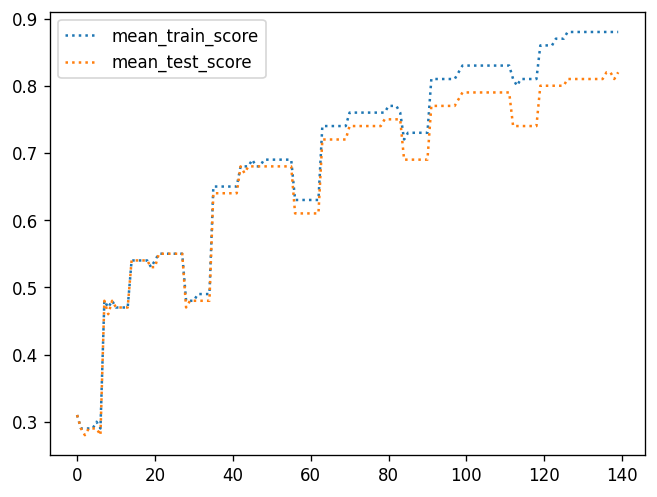

In [24]:
plt.figure(dpi=120)
plt.plot(mean_train_score, ':', label='mean_train_score')
plt.plot(mean_test_score, ':', label='mean_test_score')
plt.legend()
plt.show()

In [25]:
grid_search.best_params_

{'max_depth': 10, 'max_features': 6, 'n_estimators': 350}

In [26]:
results['params']

[{'max_depth': 2, 'max_features': 1, 'n_estimators': 50},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 100},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 150},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 200},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 250},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 300},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 350},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 50},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 100},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 150},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 200},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 250},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 300},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 350},
 {'max_depth': 2, 'max_features': 5, 'n_estimators': 50},
 {'max_depth': 2, 'max_features': 5, 'n_estimators': 100},
 {'max_depth': 2, 'max_features': 5, 'n_estimators': 150},


In [27]:
for i in range(len(mean_test_score)):
    print(f"{mean_train_score[i]}  {mean_test_score[i]}  {results['params'][i]}")
    print()

0.31  0.31  {'max_depth': 2, 'max_features': 1, 'n_estimators': 50}

0.29  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 100}

0.29  0.28  {'max_depth': 2, 'max_features': 1, 'n_estimators': 150}

0.29  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 200}

0.29  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 250}

0.3  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 300}

0.29  0.28  {'max_depth': 2, 'max_features': 1, 'n_estimators': 350}

0.48  0.48  {'max_depth': 2, 'max_features': 3, 'n_estimators': 50}

0.47  0.46  {'max_depth': 2, 'max_features': 3, 'n_estimators': 100}

0.48  0.48  {'max_depth': 2, 'max_features': 3, 'n_estimators': 150}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 200}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 250}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 300}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 350}

0.54  0.54  {'max_depth

In [28]:
import pickle

In [29]:
with open('grid_search.pkl', 'wb') as f:
    pickle.dump(grid_search, f)

In [30]:
grid_search.best_estimator_

RandomForestRegressor(max_depth=10, max_features=6, n_estimators=350, n_jobs=-1)

In [31]:
grid_search.best_params_

{'max_depth': 10, 'max_features': 6, 'n_estimators': 350}

In [32]:
grid_search.cv

5

In [33]:
grid_search.cv_results_

{'mean_fit_time': array([0.06890187, 0.11380749, 0.16883659, 0.21107287, 0.24783287,
        0.2975266 , 0.34992232, 0.07776365, 0.13976498, 0.20337367,
        0.24725947, 0.31051545, 0.37484741, 0.44225039, 0.08834753,
        0.15846372, 0.2319654 , 0.30299559, 0.37197618, 0.45125284,
        0.52829628, 0.09847736, 0.18558221, 0.28267899, 0.37287331,
        0.45395842, 0.55089865, 0.63976822, 0.08020501, 0.14128809,
        0.21968346, 0.27380643, 0.33994036, 0.40242081, 0.46990652,
        0.10906858, 0.19613485, 0.29277587, 0.37910295, 0.48405385,
        0.56973643, 0.77065926, 0.15362406, 0.31861763, 0.41762137,
        0.54608769, 0.68348436, 0.81578331, 0.96160355, 0.17120657,
        0.32660956, 0.47983885, 0.66055589, 0.80027609, 0.96140532,
        1.10079398, 0.09612818, 0.16830106, 0.23840141, 0.31385183,
        0.39225478, 0.47854204, 0.58858237, 0.15376391, 0.28163095,
        0.4195302 , 0.53953815, 0.6829937 , 0.81373515, 0.93370609,
        0.2153223 , 0.41352215,

In [34]:
7 * 5 * 4

140

In [35]:
results = grid_search.cv_results_
results

{'mean_fit_time': array([0.06890187, 0.11380749, 0.16883659, 0.21107287, 0.24783287,
        0.2975266 , 0.34992232, 0.07776365, 0.13976498, 0.20337367,
        0.24725947, 0.31051545, 0.37484741, 0.44225039, 0.08834753,
        0.15846372, 0.2319654 , 0.30299559, 0.37197618, 0.45125284,
        0.52829628, 0.09847736, 0.18558221, 0.28267899, 0.37287331,
        0.45395842, 0.55089865, 0.63976822, 0.08020501, 0.14128809,
        0.21968346, 0.27380643, 0.33994036, 0.40242081, 0.46990652,
        0.10906858, 0.19613485, 0.29277587, 0.37910295, 0.48405385,
        0.56973643, 0.77065926, 0.15362406, 0.31861763, 0.41762137,
        0.54608769, 0.68348436, 0.81578331, 0.96160355, 0.17120657,
        0.32660956, 0.47983885, 0.66055589, 0.80027609, 0.96140532,
        1.10079398, 0.09612818, 0.16830106, 0.23840141, 0.31385183,
        0.39225478, 0.47854204, 0.58858237, 0.15376391, 0.28163095,
        0.4195302 , 0.53953815, 0.6829937 , 0.81373515, 0.93370609,
        0.2153223 , 0.41352215,

In [36]:
results['mean_fit_time'].size

140

In [37]:
results.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])